---
## 1. Dataset Loading & Quick Inspection


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score, accuracy_score)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import IsolationForest
import re
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# Load dataset
df_raw = pd.read_csv('Data.csv')

print(f"Dataset Shape: {df_raw.shape}")
print(f"\nRows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
df_raw.head()


Dataset Shape: (383, 9)

Rows: 383, Columns: 9


,Unnamed: 0,Trek,Cost,Time,Trip Grade,Max Altitude,Accomodation,Best Travel Time,Contact or Book your Trip
0,0,Everest Base Camp Trek,"\r\n$1,420 USD",16 Days,Moderate,5545 m,Hotel/Guesthouse,March - May & Sept - Dec,https://www.nepalhikingteam.com
1,1,Everest Base Camp Short Trek,"\r\n$1,295 USD",14 Days,Moderate,5545 m,Hotel/Guesthouse,March - May & Sept - Dec,https://www.nepalhikingteam.com
2,2,Everest Base Camp Heli Shuttle Trek,\r\n$2000 USD,12 Days,Moderate,5545 m,Hotel/Guesthouse,March - May & Sept - Dec,https://www.nepalhikingteam.com
3,3,Everest Base Camp Heli Trek,"\r\n$3,300 USD",11 Days,Moderate,5545 m,Hotel/Guesthouse,March - May & Sept - Dec,https://www.nepalhikingteam.com
4,4,Everest Base Camp Trek for Seniors,"\r\n$1,800 USD",20 Days,Moderate,5545 m,Hotel/Guesthouse,March - May & Sept - Dec,https://www.nepalhikingteam.com


In [3]:
# Dataset info
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 383 non-null    int64 
 1   Trek                       383 non-null    object
 2   Cost                       383 non-null    object
 3   Time                       383 non-null    object
 4   Trip Grade                 383 non-null    object
 5   Max Altitude               383 non-null    object
 6   Accomodation               133 non-null    object
 7   Best Travel Time           133 non-null    object
 8   Contact or Book your Trip  383 non-null    object
dtypes: int64(1), object(8)
memory usage: 27.1+ KB


In [4]:
# Statistical summary
df_raw.describe(include='all')


,Unnamed: 0,Trek,Cost,Time,Trip Grade,Max Altitude,Accomodation,Best Travel Time,Contact or Book your Trip
count,383.00000,383,383,383,383,383,133,133,383
unique,NaN,79,167,28,11,43,8,13,3
top,NaN,Annapurna Base Camp Trek,"$1,499 USD",14 Days,Moderate,"5,545m",Hotel/Guesthouse,March - May & Sept - Dec,https://www.himalayanglacier.com
freq,NaN,10,36,56,92,55,62,36,185
mean,191.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,110.70682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,95.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,191.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,286.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Check null values
null_counts = df_raw.isnull().sum()
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})


,Null Count,Null %
Unnamed: 0,0,0.00
Trek,0,0.00
Cost,0,0.00
Time,0,0.00
Trip Grade,0,0.00
Max Altitude,0,0.00
Accomodation,250,65.27
Best Travel Time,250,65.27
Contact or Book your Trip,0,0.00


In [6]:
# Unique values per column
for col in df_raw.columns:
    print(f"{col}: {df_raw[col].nunique()} unique values")


Unnamed: 0: 383 unique values
Trek: 79 unique values
Cost: 167 unique values
Time: 28 unique values
Trip Grade: 11 unique values
Max Altitude: 43 unique values
Accomodation: 8 unique values
Best Travel Time: 13 unique values
Contact or Book your Trip: 3 unique values


---
## 2. Data Cleaning & Preprocessing

The raw dataset has several issues:
- All numeric fields (Cost, Time, Max Altitude) are stored as messy strings
- `Accomodation` and `Best Travel Time` have ~65% missing values
- `Trip Grade` has inconsistent naming (11 categories that can be simplified)
- Same trek appears multiple times from different agencies (383 rows → 79 unique treks)


In [7]:
# Start with a clean copy
df = df_raw.copy()

# Drop the unnecessary index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns='Unnamed: 0', inplace=True)

# Drop the booking URL column (not needed for analysis)
if 'Contact or Book your Trip' in df.columns:
    df.drop(columns='Contact or Book your Trip', inplace=True)

print(f"Columns after cleanup: {df.columns.tolist()}")
print(f"Shape: {df.shape}")


Columns after cleanup: ['Trek', 'Cost', 'Time', 'Trip Grade', 'Max Altitude', 'Accomodation', 'Best Travel Time']
Shape: (383, 7)


### 2.1 Clean `Cost` Column
Extract numeric USD values from messy strings like `\r\n$1,420     USD`


In [8]:
# Clean Cost: extract numeric value
def clean_cost(cost_str):
    if pd.isna(cost_str):
        return np.nan
    # Remove everything except digits, commas, and dots
    cleaned = re.sub(r'[^\d,.]', '', str(cost_str))
    # Remove commas
    cleaned = cleaned.replace(',', '')
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

df['Cost_USD'] = df['Cost'].apply(clean_cost)

print("Cost cleaning results:")
print(f"  Original sample: {df['Cost'].iloc[0]!r}")
print(f"  Cleaned sample:  {df['Cost_USD'].iloc[0]}")
print(f"  Nulls after cleaning: {df['Cost_USD'].isna().sum()}")
print(f"  Range: ${df['Cost_USD'].min():.0f} - ${df['Cost_USD'].max():.0f}")


Cost cleaning results:
  Original sample: '\r\n$1,420     USD'
  Cleaned sample:  1420.0
  Nulls after cleaning: 0
  Range: $450 - $4200


### 2.2 Clean `Time` Column
Extract number of days from strings like `16 Days`


In [9]:
# Clean Time: extract number of days
def clean_duration(time_str):
    if pd.isna(time_str):
        return np.nan
    match = re.search(r'(\d+)', str(time_str))
    return int(match.group(1)) if match else np.nan

df['Duration_Days'] = df['Time'].apply(clean_duration)

print("Duration cleaning results:")
print(f"  Original sample: {df['Time'].iloc[0]!r}")
print(f"  Cleaned sample:  {df['Duration_Days'].iloc[0]} days")
print(f"  Nulls: {df['Duration_Days'].isna().sum()}")
print(f"  Range: {df['Duration_Days'].min():.0f} - {df['Duration_Days'].max():.0f} days")


Duration cleaning results:
  Original sample: ' 16 Days'
  Cleaned sample:  16 days
  Nulls: 0
  Range: 5 - 27 days


### 2.3 Clean `Max Altitude` Column
Normalize altitude values from various formats like `5,545m`, `5545 m`, `4200m`


In [10]:
# Clean Max Altitude: extract meters
def clean_altitude(alt_str):
    if pd.isna(alt_str):
        return np.nan
    cleaned = re.sub(r'[^\d,.]', '', str(alt_str))
    cleaned = cleaned.replace(',', '')
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

df['Altitude_m'] = df['Max Altitude'].apply(clean_altitude)

print("Altitude cleaning results:")
print(f"  Original sample: {df['Max Altitude'].iloc[0]!r}")
print(f"  Cleaned sample:  {df['Altitude_m'].iloc[0]:.0f} m")
print(f"  Nulls: {df['Altitude_m'].isna().sum()}")
print(f"  Range: {df['Altitude_m'].min():.0f}m - {df['Altitude_m'].max():.0f}m")


Altitude cleaning results:
  Original sample: '5545 m'
  Cleaned sample:  5545 m
  Nulls: 0
  Range: 1550m - 6340m


### 2.4 Standardize `Trip Grade`
Map 11 inconsistent categories to a unified difficulty scale (1-5)


In [11]:
# Standardize Trip Grade and map to numeric
print("Original Trip Grade distribution:")
print(df['Trip Grade'].value_counts())
print()

# Difficulty mapping (1=easiest, 5=hardest)
difficulty_map = {
    'Light': 1,
    'Easy': 1,
    'Light+Moderate': 2,
    'Easy-Moderate': 2,
    'Easy To Moderate': 2,
    'Moderate': 3,
    'Moderate-Hard': 3,
    'Moderate+Demanding': 4,
    'Demanding': 4,
    'Demanding+Challenging': 5,
    'Strenuous': 5
}

df['Difficulty_Score'] = df['Trip Grade'].map(difficulty_map)

print("\nMapped Difficulty Score distribution:")
print(df['Difficulty_Score'].value_counts().sort_index())


Original Trip Grade distribution:
Trip Grade
Moderate                 92
Demanding                75
Easy To Moderate         58
Moderate+Demanding       40
Moderate-Hard            30
Easy                     25
Strenuous                23
Demanding+Challenging    20
Easy-Moderate            10
Light+Moderate            5
Light                     5
Name: count, dtype: int64


Mapped Difficulty Score distribution:
Difficulty_Score
1     30
2     73
3    122
4    115
5     43
Name: count, dtype: int64


### 2.5 Clean `Accomodation` Column
Fill missing values and standardize accommodation types


In [12]:
# Standardize Accommodation
accommodation_map = {
    'Hotel/Guesthouse': 'Guesthouse',
    'Hotel/Guest Houses': 'Guesthouse',
    'Hotel/Guesthouses': 'Guesthouse',
    'Hotel/Teahouses': 'Teahouse',
    'Hotel/Teahouse': 'Teahouse',
    'Teahouses/Lodges': 'Teahouse',
    'Hotel/Lodges': 'Lodge',
    'Hotel/Luxury Lodges': 'Luxury Lodge'
}

df['Accomodation'] = df['Accomodation'].fillna('Guesthouse')
df['Accommodation_Type'] = df['Accomodation'].map(accommodation_map).fillna('Guesthouse')

# Map to comfort score (1=basic, 4=luxury)
comfort_map = {
    'Teahouse': 1,
    'Guesthouse': 2,
    'Lodge': 3,
    'Luxury Lodge': 4
}
df['Comfort_Score'] = df['Accommodation_Type'].map(comfort_map)

print("Accommodation distribution after standardization:")
print(df['Accommodation_Type'].value_counts())


Accommodation distribution after standardization:
Accommodation_Type
Guesthouse      322
Teahouse         46
Lodge            10
Luxury Lodge      5
Name: count, dtype: int64


### 2.6 Clean `Best Travel Time`
Standardize and fill missing values


In [13]:
# Fill missing Best Travel Time with mode
df['Best Travel Time'] = df['Best Travel Time'].fillna('March - May & Sept - Dec')

# Standardize format
def standardize_season(s):
    if pd.isna(s):
        return 'March - May & Sept - Dec'
    s = str(s).strip().rstrip('.')
    s = s.replace('Setpt', 'Sept')  # Fix typo in data
    return s

df['Best_Season'] = df['Best Travel Time'].apply(standardize_season)

print("Best Season distribution:")
print(df['Best_Season'].value_counts())


Best Season distribution:
Best_Season
March - May & Sept - Dec    298
March - May & Sept - Nov     41
March-May & Sept-Dec         16
Jan - May & Sept - Dec       12
March - Nov                   5
Jan- May & Sept - Dec         5
Jan - May & Sept- Dec         5
April - May & Sept - Nov      1
Name: count, dtype: int64


### 2.7 Deduplicate Treks
Aggregate multiple listings of the same trek by taking median values


In [14]:
# Count duplicates
print(f"Total rows: {len(df)}")
print(f"Unique trek names: {df['Trek'].nunique()}")
print(f"\nMost duplicated treks:")
print(df['Trek'].value_counts().head(10))


Total rows: 383
Unique trek names: 79

Most duplicated treks:
Trek
Annapurna Base Camp Trek          10
Annapurna Circuit Trek            10
Mardi Himal Trek                  10
Manaslu Circuit Trek              10
Upper Mustang Trek                10
Everest Base Camp Heli Trek        6
Everest Base Camp Trek             6
Everest Panorama Trek              6
Annapurna Base Camp Heli Trek      5
Classic Annapurna Circuit Trek     5
Name: count, dtype: int64


In [15]:
# Aggregate to unique treks using median for numeric, mode for categorical
numeric_agg = {
    'Cost_USD': 'median',
    'Duration_Days': 'median',
    'Altitude_m': 'median',
    'Difficulty_Score': 'median',
    'Comfort_Score': 'median'
}

# Group by trek name
df_grouped = df.groupby('Trek').agg(numeric_agg).reset_index()

# Round the aggregated values
df_grouped['Duration_Days'] = df_grouped['Duration_Days'].round().astype(int)
df_grouped['Difficulty_Score'] = df_grouped['Difficulty_Score'].round().astype(int)
df_grouped['Comfort_Score'] = df_grouped['Comfort_Score'].round().astype(int)

# Get the most common season and accommodation for each trek
season_mode = df.groupby('Trek')['Best_Season'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'March - May & Sept - Dec').reset_index()
accom_mode = df.groupby('Trek')['Accommodation_Type'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Guesthouse').reset_index()

df_clean = df_grouped.merge(season_mode, on='Trek').merge(accom_mode, on='Trek')

print(f"\n✅ Deduplicated: {len(df)} rows → {len(df_clean)} unique treks")
print(f"\nCleaned dataset shape: {df_clean.shape}")
df_clean.head(10)



✅ Deduplicated: 383 rows → 79 unique treks

Cleaned dataset shape: (79, 8)


,Trek,Cost_USD,Duration_Days,Altitude_m,Difficulty_Score,Comfort_Score,Best_Season,Accommodation_Type
0,Annapurna Base Camp Heli Trek,1750.0,9,4210.0,2,1,March - May & Sept - Dec,Teahouse
1,Annapurna Base Camp Short Trek,1090.0,11,4210.0,2,1,March - May & Sept - Dec,Teahouse
2,Annapurna Base Camp Trek,1090.0,15,4170.0,3,2,March - May & Sept - Dec,Guesthouse
3,Annapurna Base Camp Trek,1499.0,11,4130.0,4,2,March - May & Sept - Dec,Guesthouse
4,Annapurna Circle Trek,1499.0,14,5416.0,4,2,March - May & Sept - Dec,Guesthouse
5,Annapurna Circuit Short Trek,1250.0,12,5416.0,5,2,March - May & Sept - Nov,Guesthouse
6,Annapurna Circuit Trek,1175.0,16,5416.0,3,2,March - May & Sept - Dec,Guesthouse
7,Annapurna Circuit Trek with Tilicho Lake and P...,1499.0,20,5416.0,4,2,March - May & Sept - Dec,Guesthouse
8,Annapurna Circuit Trek,1499.0,17,5416.0,4,2,March - May & Sept - Dec,Guesthouse
9,Annapurna Luxury Trek,1450.0,9,2012.0,2,4,March - May & Sept - Dec,Luxury Lodge


---
## 3. Feature Engineering — Trek DNA Scores

Following the TrekVerse documentation, we engineer **5 normalized scores** (0-1 scale) that form each trek's "DNA":

| Score | Description | Based On |
|-------|-------------|----------|
| **Adventure** | How thrilling/extreme the trek is | Difficulty + Altitude |
| **Comfort** | Level of accommodation quality | Accommodation type |
| **Remoteness** | How isolated/off-the-beaten-path | Altitude + Difficulty + inverse Comfort |
| **Effort** | Physical demands required | Duration + Difficulty + Altitude |
| **Scenic Value** | Visual/natural beauty potential | Altitude diversity + Season breadth |


In [16]:
# Feature Engineering: Trek DNA Scores

scaler = MinMaxScaler()

# Normalize base features to 0-1
df_clean['norm_altitude'] = scaler.fit_transform(df_clean[['Altitude_m']])
df_clean['norm_duration'] = scaler.fit_transform(df_clean[['Duration_Days']])
df_clean['norm_difficulty'] = scaler.fit_transform(df_clean[['Difficulty_Score']])
df_clean['norm_comfort'] = scaler.fit_transform(df_clean[['Comfort_Score']])
df_clean['norm_cost'] = scaler.fit_transform(df_clean[['Cost_USD']])

# 1. Adventure Score = 0.6 * difficulty + 0.4 * altitude
df_clean['Adventure_Score'] = (0.6 * df_clean['norm_difficulty'] + 0.4 * df_clean['norm_altitude'])

# 2. Comfort Score (already normalized from accommodation)
df_clean['Comfort_DNA'] = df_clean['norm_comfort']

# 3. Remoteness Score = 0.4 * altitude + 0.3 * difficulty + 0.3 * (1 - comfort)
df_clean['Remoteness_Score'] = (0.4 * df_clean['norm_altitude'] + 
                                 0.3 * df_clean['norm_difficulty'] + 
                                 0.3 * (1 - df_clean['norm_comfort']))

# 4. Effort Score = 0.35 * duration + 0.35 * difficulty + 0.3 * altitude
df_clean['Effort_Score'] = (0.35 * df_clean['norm_duration'] + 
                             0.35 * df_clean['norm_difficulty'] + 
                             0.30 * df_clean['norm_altitude'])

# 5. Scenic Value = 0.5 * altitude_variety + 0.3 * altitude + 0.2 * season_breadth
# Season breadth: more months available = higher scenic value
def count_season_months(season_str):
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    count = sum(1 for m in months if m.lower() in str(season_str).lower())
    return max(count, 2)  # minimum 2 months

df_clean['season_months'] = df_clean['Best_Season'].apply(count_season_months)
df_clean['norm_season'] = scaler.fit_transform(df_clean[['season_months']])

df_clean['Scenic_Score'] = (0.4 * df_clean['norm_altitude'] + 
                             0.3 * (1 - df_clean['norm_difficulty']) +  # easier = more scenic enjoyment
                             0.3 * df_clean['norm_season'])

# Normalize all DNA scores to 0-1 range
dna_cols = ['Adventure_Score', 'Comfort_DNA', 'Remoteness_Score', 'Effort_Score', 'Scenic_Score']
for col in dna_cols:
    df_clean[col] = scaler.fit_transform(df_clean[[col]])

print("✅ Trek DNA Scores engineered!")
print(f"\nScore statistics:")
df_clean[dna_cols].describe().round(3)


✅ Trek DNA Scores engineered!

Score statistics:


,Adventure_Score,Comfort_DNA,Remoteness_Score,Effort_Score,Scenic_Score
count,79.000,79.000,79.000,79.000,79.000
mean,0.622,0.312,0.724,0.612,0.664
std,0.258,0.145,0.223,0.242,0.219
min,0.000,0.000,0.000,0.000,0.000
25%,0.399,0.333,0.588,0.462,0.505
50%,0.666,0.333,0.792,0.648,0.707
75%,0.821,0.333,0.894,0.792,0.824
max,1.000,1.000,1.000,1.000,1.000


In [17]:
# Display Trek DNA for sample treks
sample_treks = ['Everest Base Camp Trek', 'Annapurna Base Camp Trek', 
                'Manaslu Circuit Trek', 'Mardi Himal Trek', 'Upper Mustang Trek']

# Filter only treks that exist in the dataset
sample_treks = [t for t in sample_treks if t in df_clean['Trek'].values]

display_cols = ['Trek', 'Cost_USD', 'Duration_Days', 'Altitude_m', 'Difficulty_Score'] + dna_cols
df_clean[df_clean['Trek'].isin(sample_treks)][display_cols].round(3)


,Trek,Cost_USD,Duration_Days,Altitude_m,Difficulty_Score,Adventure_Score,Comfort_DNA,Remoteness_Score,Effort_Score,Scenic_Score
2,Annapurna Base Camp Trek,1090.0,15,4170.0,3,0.537,0.333,0.632,0.558,0.600
22,Everest Base Camp Trek,1450.0,16,5545.0,3,0.666,0.333,0.792,0.679,0.909
53,Manaslu Circuit Trek,1320.0,16,5163.0,4,0.797,0.333,0.852,0.755,0.621
57,Mardi Himal Trek,720.0,9,4350.0,2,0.387,0.333,0.549,0.355,0.842
76,Upper Mustang Trek,2125.0,17,4205.0,2,0.373,0.333,0.532,0.495,0.810


---
## 4. Exploratory Data Analysis (EDA)


### 4.1 Distribution of Key Features

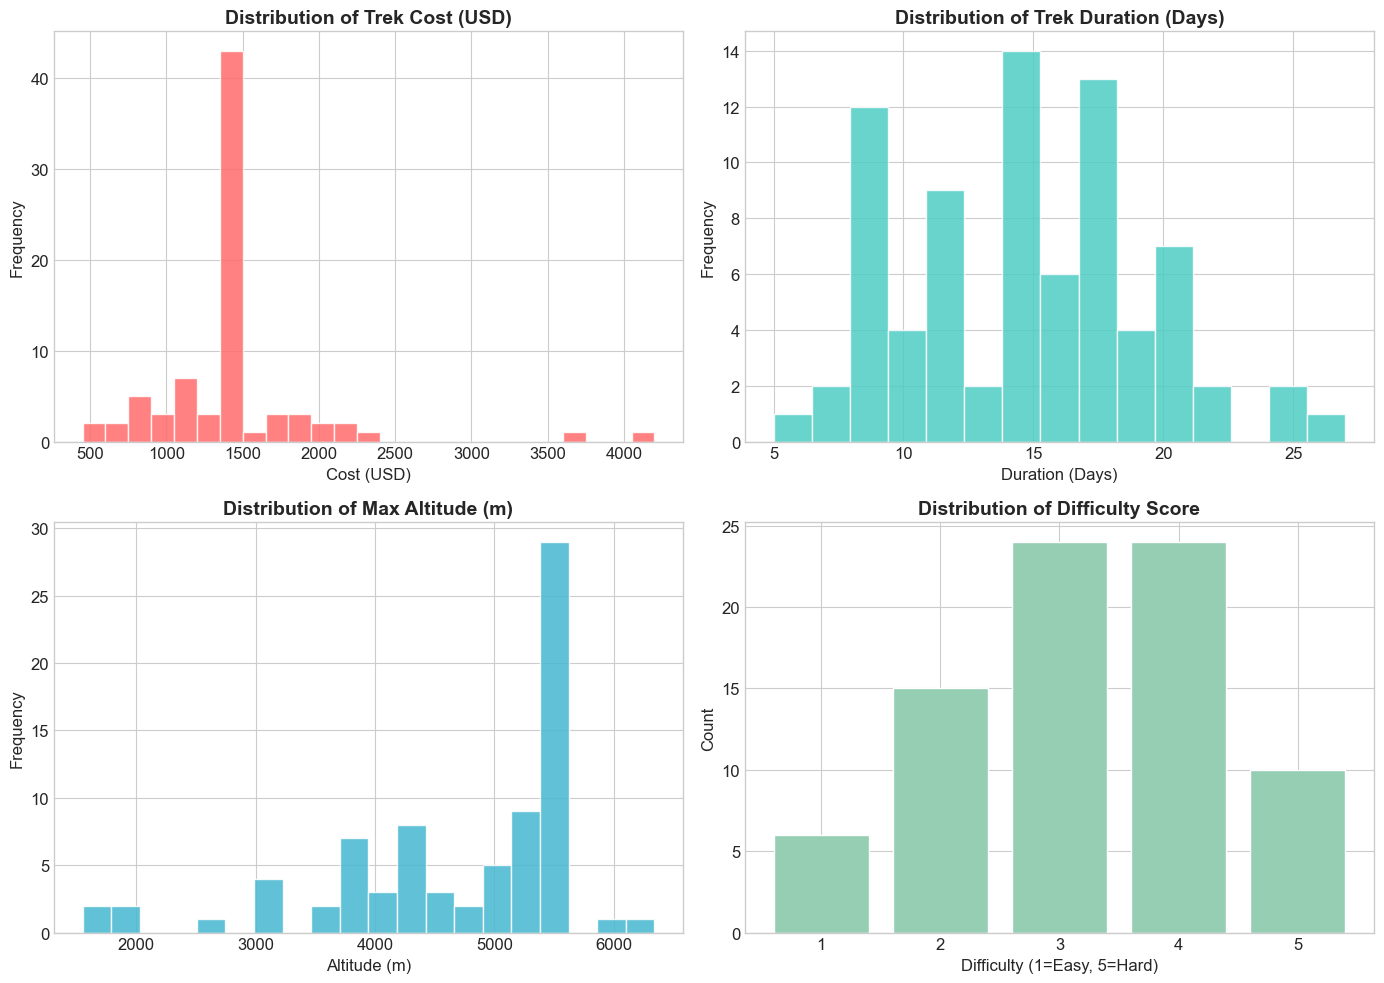

📊 Distributions saved to eda_distributions.png


In [18]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cost distribution
axes[0, 0].hist(df_clean['Cost_USD'], bins=25, color='#FF6B6B', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Distribution of Trek Cost (USD)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Cost (USD)')
axes[0, 0].set_ylabel('Frequency')

# Duration distribution
axes[0, 1].hist(df_clean['Duration_Days'], bins=15, color='#4ECDC4', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Distribution of Trek Duration (Days)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Duration (Days)')
axes[0, 1].set_ylabel('Frequency')

# Altitude distribution
axes[1, 0].hist(df_clean['Altitude_m'], bins=20, color='#45B7D1', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Distribution of Max Altitude (m)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Altitude (m)')
axes[1, 0].set_ylabel('Frequency')

# Difficulty distribution
difficulty_counts = df_clean['Difficulty_Score'].value_counts().sort_index()
axes[1, 1].bar(difficulty_counts.index, difficulty_counts.values, color='#96CEB4', edgecolor='white')
axes[1, 1].set_title('Distribution of Difficulty Score', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Difficulty (1=Easy, 5=Hard)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Distributions saved to eda_distributions.png")


### 4.2 Correlation Heatmap

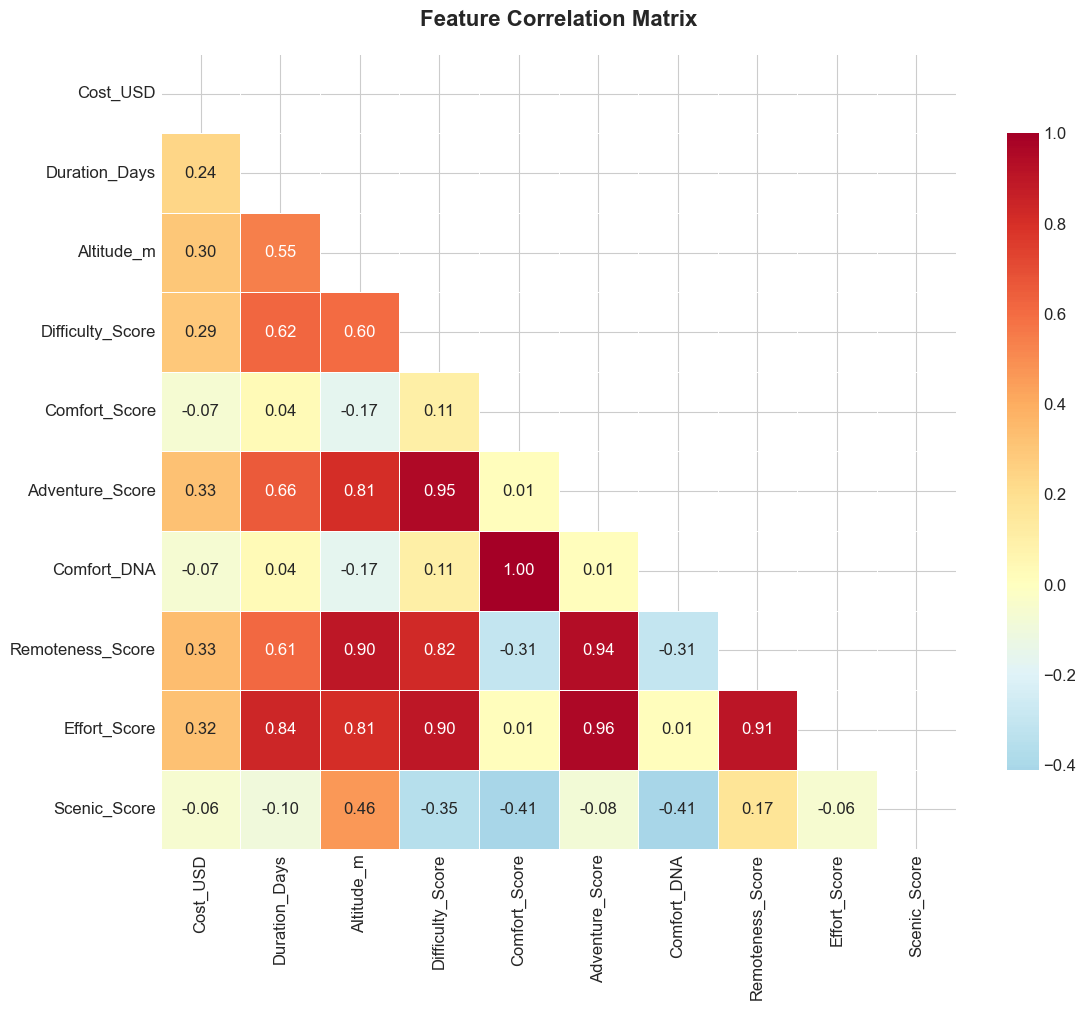

In [19]:
# Correlation heatmap
numeric_cols = ['Cost_USD', 'Duration_Days', 'Altitude_m', 'Difficulty_Score', 
                'Comfort_Score'] + dna_cols

corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Top Treks Analysis

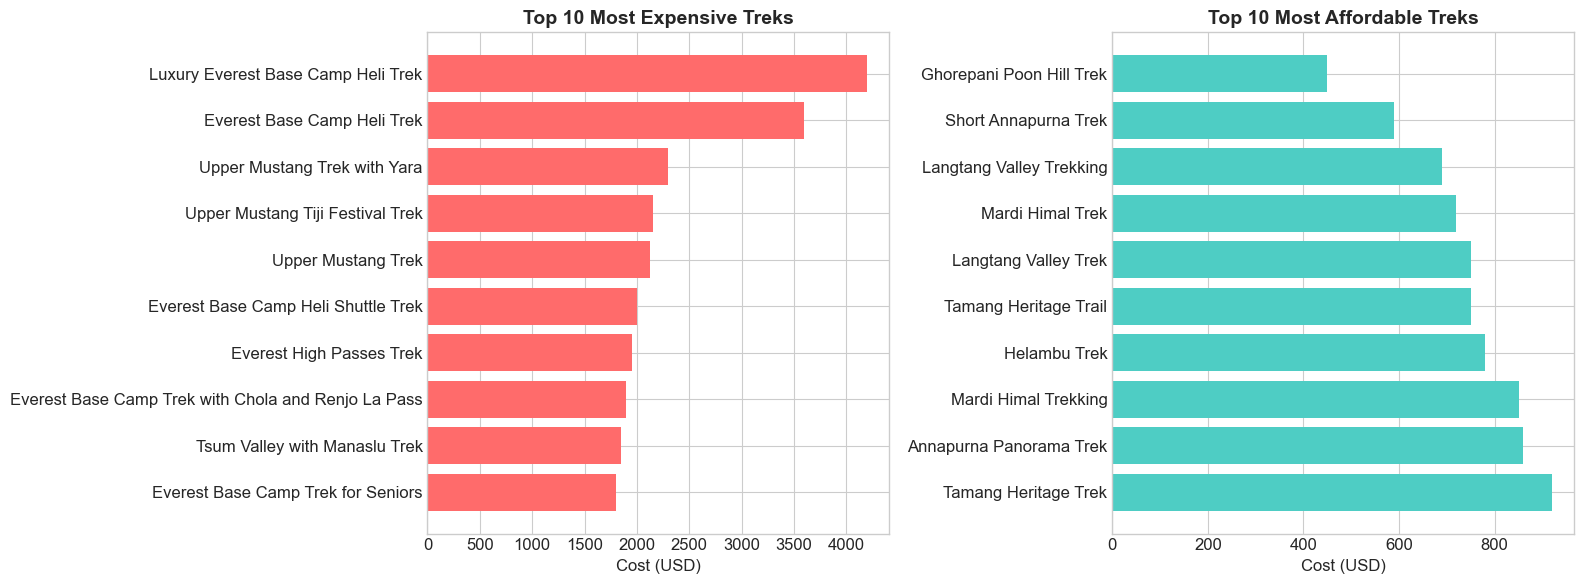

In [20]:
# Top 10 most expensive and cheapest treks
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Most expensive
top_expensive = df_clean.nlargest(10, 'Cost_USD')[['Trek', 'Cost_USD']]
axes[0].barh(top_expensive['Trek'], top_expensive['Cost_USD'], color='#FF6B6B')
axes[0].set_title('Top 10 Most Expensive Treks', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cost (USD)')
axes[0].invert_yaxis()

# Cheapest
top_cheap = df_clean.nsmallest(10, 'Cost_USD')[['Trek', 'Cost_USD']]
axes[1].barh(top_cheap['Trek'], top_cheap['Cost_USD'], color='#4ECDC4')
axes[1].set_title('Top 10 Most Affordable Treks', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cost (USD)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_top_treks.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.4 Cost by Difficulty Level

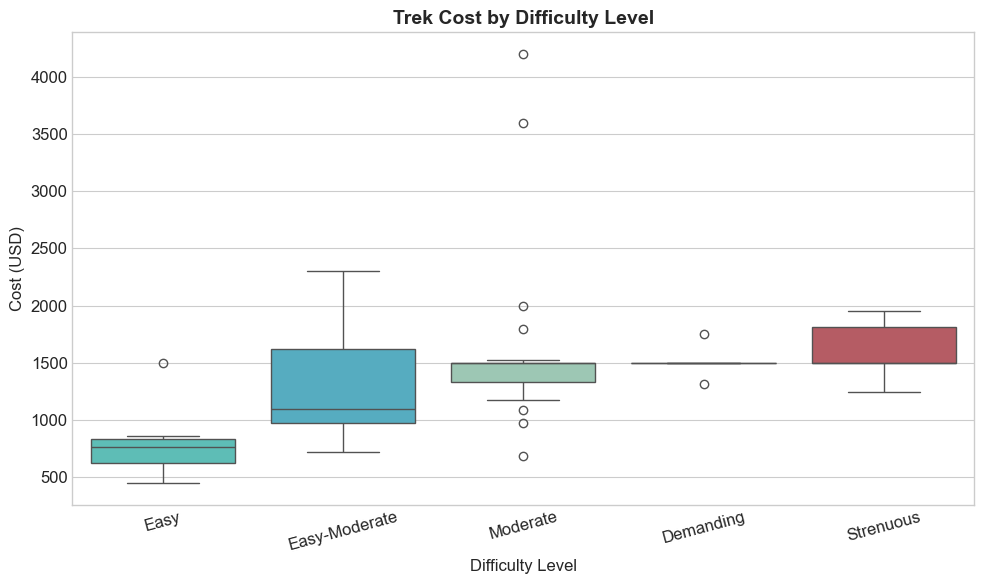

In [21]:
# Box plot: Cost by Difficulty
fig, ax = plt.subplots(figsize=(10, 6))
difficulty_labels = {1: 'Easy', 2: 'Easy-Moderate', 3: 'Moderate', 4: 'Demanding', 5: 'Strenuous'}
df_plot = df_clean.copy()
df_plot['Difficulty_Label'] = df_plot['Difficulty_Score'].map(difficulty_labels)

order = ['Easy', 'Easy-Moderate', 'Moderate', 'Demanding', 'Strenuous']
colors = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FF6B6B', '#C44D58']

sns.boxplot(data=df_plot, x='Difficulty_Label', y='Cost_USD', order=order, palette=colors, ax=ax)
ax.set_title('Trek Cost by Difficulty Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Difficulty Level')
ax.set_ylabel('Cost (USD)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('eda_cost_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()
